# Week 3 — PCA vs NMF: denoising and unmixing EELS spectrum images

**Course:** Data Science for Electron Microscopy — FAU Erlangen-Nürnberg
**Author:** Prof. Dr. Philipp Pelz
**Prerequisites:** Week 1 (NumPy, matplotlib) · Week 2 (Poisson noise, noise model → loss)
**Time budget:** ~2 hours for a beginner working steadily · runs end-to-end on a CPU in < 1 min

## What you will do

**Part A — PCA denoising (line scan)**

1. Build a **synthetic EELS spectral line scan** with two latent chemical components and Poisson noise.
2. Compute the **SVD** of the centered data matrix and plot the **scree plot**.
3. **Reconstruct** with different numbers of components; find the optimal K (U-shaped error curve).
4. **Exercise:** choose K yourself and justify from the scree plot.

**Part B–D — PCA vs NMF (2-D spectrum image with ground truth)**

5. Build a **3-phase 2-D spectrum image** (TiO₂-like, FeO-like, Ni) with a *known* ground truth.
6. Run **PCA** and **NMF** and compare the recovered endmember spectra and abundance maps against the truth, quantitatively.
7. **Exercise:** implement NMF **multiplicative updates** yourself.
8. **Experiment:** watch **rotational ambiguity** happen — restart NMF on data without pure pixels.
9. *Optional:* a minimal **MCR-ALS** with non-negativity + closure.

## How to use this notebook

All exercise code cells ship a **working version** with `# (try this yourself)` markers.
**Instructions:** before running those cells, try to write the code yourself (the comment tells you which lines to try).
A separate **Solution** markdown cell follows each exercise with a plain-code block.
Run `nbconvert --execute` end-to-end any time — it will always succeed.

---

In [1]:
# --- Cell 1: Install and import ---
# Run this cell first (works on Colab; harmless on a local install)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "numpy", "scipy", "matplotlib",
                "scikit-learn", "--quiet"], check=True)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, NMF
from scipy.optimize import linear_sum_assignment

rng = np.random.default_rng(42)
print("Imports OK — NumPy", np.__version__)


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /home/philipp/projects/_public_presentations/.venv/bin/python -m pip install --upgrade pip


Imports OK — NumPy 1.26.4


## Part A1 — Build the synthetic EELS line scan

We simulate a 1-D spatial scan of 64 pixels, each with a 300-channel EELS spectrum.  
Two latent chemical components vary **independently** across the scan:

- **Component A (Fe-L edge, ~710 eV):** Gaussian bump centred in the scan (`exp(-((x-0.5)/0.15)²)`).
- **Component B (Cr-L edge, ~580 eV):** linearly decreasing from left to right (`1 - x`).

The two weight functions are **uncorrelated** (correlation ≈ 0), giving a rank-2 clean signal.  
Noise is added with `np.random.poisson` — the correct model for electron counting detectors.

In [2]:
# --- Cell 2: Define spectral components and spatial weights ---

nx    = 64           # number of spatial pixels along the line scan
ne    = 300          # number of energy channels
SCALE = 500.0        # detector gain (electrons per unit intensity)

energy = np.linspace(500, 900, ne)   # energy axis in eV

def gaussian(e, mu, sig, h):
    """Gaussian peak: centre mu (eV), width sig (eV), height h."""
    return h * np.exp(-0.5 * ((e - mu) / sig) ** 2)

# Spectral shapes for the two latent components
comp_fe = (gaussian(energy, 710, 20, 1.0)     # Fe-L3 white-line
         + gaussian(energy, 700,  8, 0.4))    # Fe-L2 shoulder

comp_cr = gaussian(energy, 580, 18, 0.8)      # Cr-L2,3 edge

# Constant background (will be absorbed into the mean spectrum after centering)
background_level = 0.30

# Spatial weight functions — designed to be UNCORRELATED
x = np.linspace(0, 1, nx)
weight_fe = np.exp(-((x - 0.5) / 0.15) ** 2)   # Gaussian bump at centre
weight_cr = 1.0 - x                              # linearly decreasing, left-to-right

# Build the clean signal matrix: shape (nx, ne)
clean = (np.outer(weight_fe, comp_fe)
       + np.outer(weight_cr, comp_cr)
       + background_level)          # constant background added uniformly

# Sanity checks
assert clean.min() > 0, "Clean signal must be strictly positive for Poisson sampling"
corr = np.corrcoef(weight_fe, weight_cr)[0, 1]
print(f"Spatial weight correlation (Fe vs Cr): {corr:.3f}  (should be ≈ 0)")
print(f"clean.shape: {clean.shape}   min: {clean.min():.3f}   max: {clean.max():.3f}")

Spatial weight correlation (Fe vs Cr): -0.000  (should be ≈ 0)
clean.shape: (64, 300)   min: 0.300   max: 1.609


Image-average SNR ≈ √(mean_counts) = 13.8
noisy.shape: (64, 300)


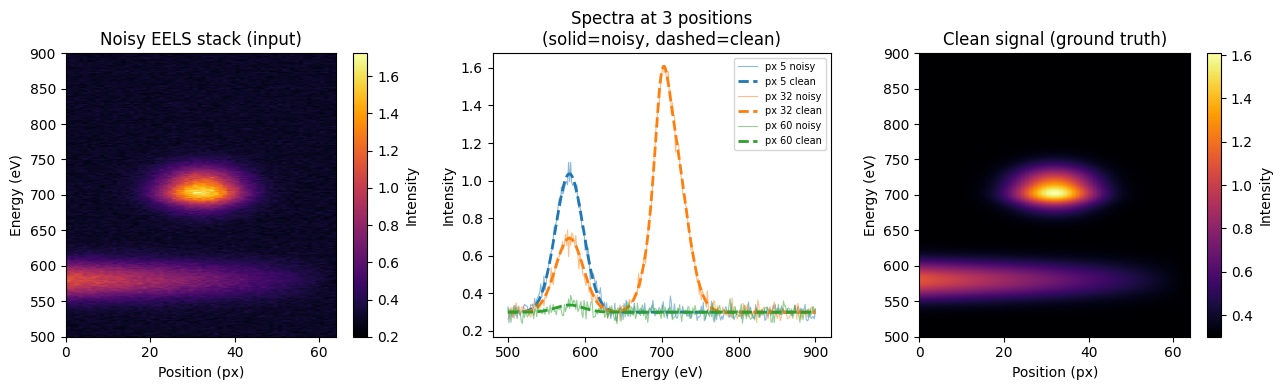


Fe-L edge: bright band ~710 eV, strongest in the centre (Gaussian bump).
Cr-L edge: bright band ~580 eV, strongest at the left edge (linear decrease).


In [3]:
# --- Cell 3: Add Poisson noise ---

noisy = rng.poisson(clean * SCALE).astype(np.float64) / SCALE

snr_avg = np.sqrt(clean.mean() * SCALE)
print(f"Image-average SNR ≈ √(mean_counts) = {snr_avg:.1f}")
print(f"noisy.shape: {noisy.shape}")

# ── Quick visualisation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

im0 = axes[0].imshow(noisy.T, aspect='auto', origin='lower',
                     extent=[0, nx, energy[0], energy[-1]], cmap='inferno')
axes[0].set_title('Noisy EELS stack (input)')
axes[0].set_xlabel('Position (px)')
axes[0].set_ylabel('Energy (eV)')
plt.colorbar(im0, ax=axes[0], label='Intensity')

for idx, col in [(5, 'C0'), (32, 'C1'), (60, 'C2')]:
    axes[1].plot(energy, noisy[idx], lw=0.8, color=col, alpha=0.5, label=f'px {idx} noisy')
    axes[1].plot(energy, clean[idx], lw=2,   color=col, linestyle='--', label=f'px {idx} clean')
axes[1].set_title('Spectra at 3 positions\n(solid=noisy, dashed=clean)')
axes[1].set_xlabel('Energy (eV)')
axes[1].set_ylabel('Intensity')
axes[1].legend(fontsize=7)

im2 = axes[2].imshow(clean.T, aspect='auto', origin='lower',
                     extent=[0, nx, energy[0], energy[-1]], cmap='inferno')
axes[2].set_title('Clean signal (ground truth)')
axes[2].set_xlabel('Position (px)')
axes[2].set_ylabel('Energy (eV)')
plt.colorbar(im2, ax=axes[2], label='Intensity')

plt.tight_layout()
plt.show()
print("\nFe-L edge: bright band ~710 eV, strongest in the centre (Gaussian bump).")
print("Cr-L edge: bright band ~580 eV, strongest at the left edge (linear decrease).")

## Part A2 — Compute the SVD

PCA is SVD of the **centered** data matrix.  
We subtract the mean spectrum (averaged over all pixels) from every row.

In [4]:
# --- Cell 4: Center and compute SVD ---

mean_spectrum = noisy.mean(axis=0)                           # (ne,) — average over pixels
X_centered    = noisy - mean_spectrum[np.newaxis, :]        # broadcast: subtract from every row

# SVD: X_centered = U @ diag(s) @ Vt
U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)

print("U.shape  :", U.shape)     # (nx, min(nx, ne))
print("s.shape  :", s.shape)     # (min(nx, ne),) — singular values, descending
print("Vt.shape :", Vt.shape)    # (min(nx, ne), ne)
print("First 10 singular values:", s[:10].round(3))
print("Note: the first two are much larger than the rest — those are the signal components.")

U.shape  : (64, 64)
s.shape  : (64,)
Vt.shape : (64, 300)
First 10 singular values: [16.86   9.14   0.703  0.677  0.672  0.655  0.642  0.62   0.615  0.607]
Note: the first two are much larger than the rest — those are the signal components.


## Part A3 — The scree plot

The scree plot shows the **variance explained** by each principal component in decreasing order.  
Signal components form a steeply declining head; noise components form a flat floor.  
The **elbow** — where the curve transitions from steep to flat — marks the signal-noise boundary.

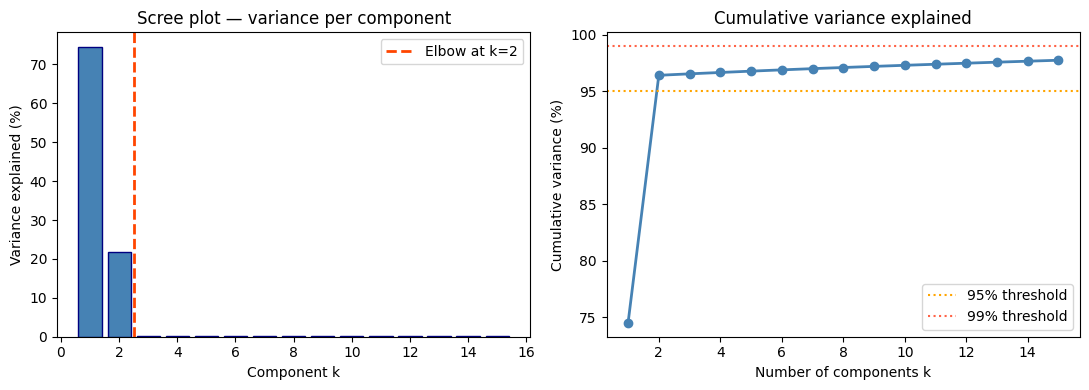

Variance: PC1=74.5%  PC2=21.9%  PC3=0.13%
Cumulative k=2: 96.4%
Components needed for 95% variance: 2


In [5]:
# --- Cell 5: Scree plot ---

var_explained = (s ** 2) / (s ** 2).sum() * 100   # percentage of total variance
cum_var       = np.cumsum(var_explained)           # cumulative

k_show = min(len(s), 15)   # show first 15 components

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Left: individual explained variance (scree plot) ─────────────────────────
axes[0].bar(np.arange(1, k_show + 1), var_explained[:k_show],
            color='steelblue', edgecolor='navy')
axes[0].axvline(2.5, color='orangered', lw=2, linestyle='--', label='Elbow at k=2')
axes[0].set_title('Scree plot — variance per component')
axes[0].set_xlabel('Component k')
axes[0].set_ylabel('Variance explained (%)')
axes[0].legend()

# ── Right: cumulative explained variance ────────────────────────────────────
axes[1].plot(np.arange(1, k_show + 1), cum_var[:k_show], 'o-', color='steelblue', lw=2)
axes[1].axhline(95, color='orange', lw=1.5, linestyle=':', label='95% threshold')
axes[1].axhline(99, color='tomato', lw=1.5, linestyle=':', label='99% threshold')
axes[1].set_title('Cumulative variance explained')
axes[1].set_xlabel('Number of components k')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Variance: PC1={var_explained[0]:.1f}%  PC2={var_explained[1]:.1f}%  PC3={var_explained[2]:.2f}%")
print(f"Cumulative k=2: {cum_var[1]:.1f}%")
k_95 = int(np.searchsorted(cum_var, 95)) + 1
print(f"Components needed for 95% variance: {k_95}")

**What you should see:**

- PC1 and PC2 bars are **much taller** than PC3+. These capture the two chemical components.
- PC3 onwards shows a flat noise floor — all roughly equal.
- The **elbow** is between k=2 and k=3.  
- Cumulative variance reaches ~95–97% with just K=2 components.

The scree plot tells you: **keep K=2 components**.

## Part A4 — Reconstruction with different K

We reconstruct the stack using K = 1, 2, 5, and 10 components.  
Then we measure the reconstruction error (Frobenius norm) against the clean ground truth.

In [6]:
# --- Cell 6: Helper functions for reconstruction and error ---

def reconstruct_pca(mean_spectrum, U, s, Vt, k):
    """Reconstruct data matrix keeping only the top-k singular components.

    Parameters
    ----------
    mean_spectrum : (D,) mean spectrum of the original data
    U, s, Vt      : SVD outputs from np.linalg.svd(X_centered, full_matrices=False)
    k             : number of components to keep

    Returns
    -------
    recon : (N, D) reconstructed (denoised) data matrix
    """
    recon_centered = (U[:, :k] * s[:k]) @ Vt[:k, :]   # truncated SVD reconstruction
    return recon_centered + mean_spectrum[np.newaxis, :]  # restore mean


def frob_error(recon, reference):
    """Frobenius norm of reconstruction error vs reference."""
    return np.sqrt(((recon - reference) ** 2).sum())


# Print error table
k_values = [1, 2, 3, 5, 10, 20]
print("K  | Frobenius error vs clean ground truth")
print("-" * 40)
for k in k_values:
    e = frob_error(reconstruct_pca(mean_spectrum, U, s, Vt, k), clean)
    print(f"K={k:2d} | {e:.4f}")
print(f"\nNoisy baseline (no denoising): {frob_error(noisy, clean):.4f}")

K  | Frobenius error vs clean ground truth
----------------------------------------
K= 1 | 9.1948
K= 2 | 0.9122
K= 3 | 1.1520
K= 5 | 1.4953
K=10 | 2.0517
K=20 | 2.7170

Noisy baseline (no denoising): 3.8048


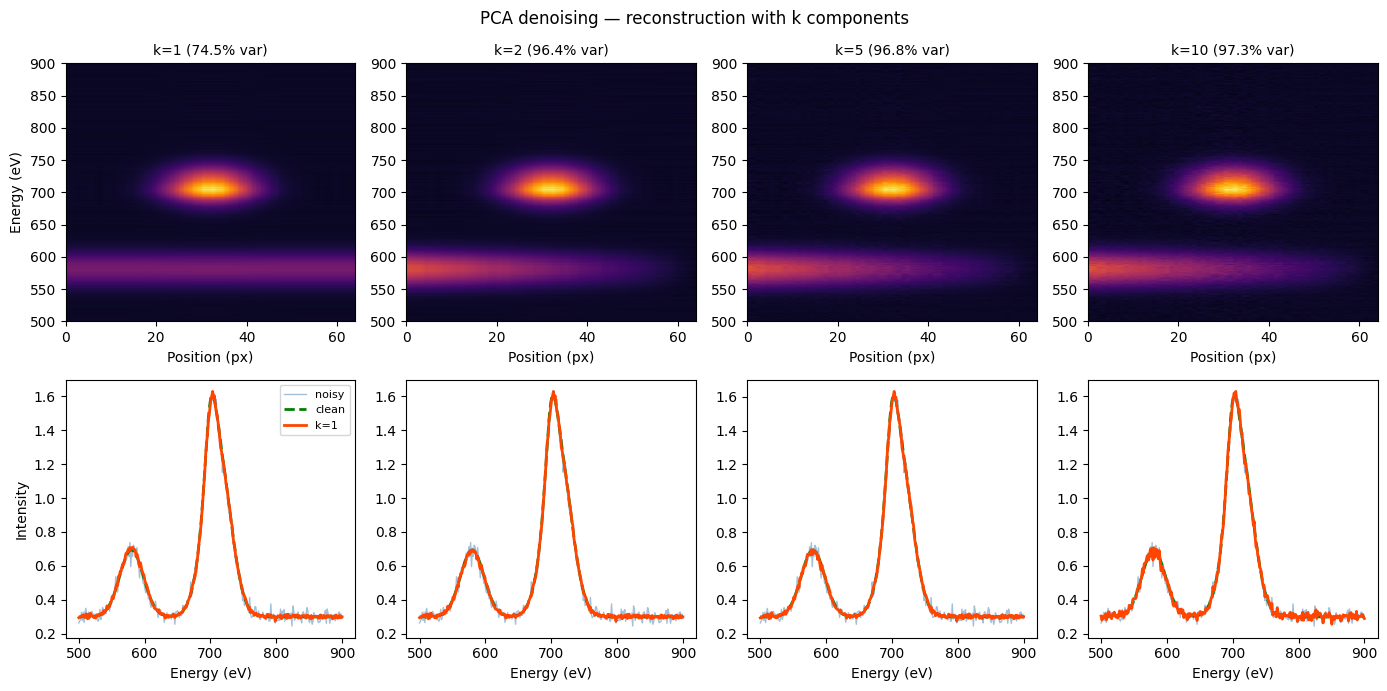

k=1 : missing the Cr-L component — underfitting (systematic error).
k=2 : closely matches clean ground truth — optimal.
k=5, 10 : extra noise components added back in — overfitting (higher error).


In [7]:
# --- Cell 7: Visualise reconstructions ---

pixel_to_show = 32   # spectrum near the centre of the scan
k_plot = [1, 2, 5, 10]

fig, axes = plt.subplots(2, len(k_plot), figsize=(14, 7))

for col, k in enumerate(k_plot):
    recon = reconstruct_pca(mean_spectrum, U, s, Vt, k)
    pct   = (s[:k] ** 2).sum() / (s ** 2).sum() * 100

    # Top row: spectral image
    axes[0][col].imshow(recon.T, aspect='auto', origin='lower',
                        extent=[0, nx, energy[0], energy[-1]],
                        cmap='inferno', vmin=noisy.min(), vmax=noisy.max())
    axes[0][col].set_title(f'k={k} ({pct:.1f}% var)', fontsize=10)
    axes[0][col].set_xlabel('Position (px)')
    if col == 0:
        axes[0][col].set_ylabel('Energy (eV)')

    # Bottom row: spectrum at centre pixel
    axes[1][col].plot(energy, noisy[pixel_to_show], lw=1, color='steelblue',
                      alpha=0.5, label='noisy')
    axes[1][col].plot(energy, clean[pixel_to_show], lw=2, color='green',
                      linestyle='--', label='clean')
    axes[1][col].plot(energy, recon[pixel_to_show], lw=2, color='orangered',
                      label=f'k={k}')
    if col == 0:
        axes[1][col].legend(fontsize=8)
    axes[1][col].set_xlabel('Energy (eV)')
    if col == 0:
        axes[1][col].set_ylabel('Intensity')

plt.suptitle('PCA denoising — reconstruction with k components', fontsize=12)
plt.tight_layout()
plt.show()

print("k=1 : missing the Cr-L component — underfitting (systematic error).")
print("k=2 : closely matches clean ground truth — optimal.")
print("k=5, 10 : extra noise components added back in — overfitting (higher error).")

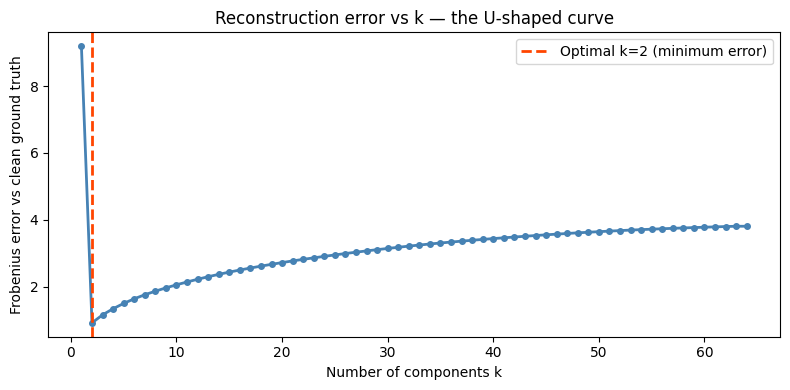

Optimal K by minimum error: 2
This matches the scree-plot elbow at K=2.


In [8]:
# --- Cell 8: Reconstruction error vs K (the U-shaped curve) ---

k_range    = np.arange(1, min(len(s) + 1, nx + 1))
error_curve = [frob_error(reconstruct_pca(mean_spectrum, U, s, Vt, k), clean)
               for k in k_range]

k_optimal = int(k_range[np.argmin(error_curve)])

plt.figure(figsize=(8, 4))
plt.plot(k_range, error_curve, 'o-', color='steelblue', lw=2, ms=4)
plt.axvline(k_optimal, color='orangered', lw=2, linestyle='--',
            label=f'Optimal k={k_optimal} (minimum error)')
plt.xlabel('Number of components k')
plt.ylabel('Frobenius error vs clean ground truth')
plt.title('Reconstruction error vs k — the U-shaped curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal K by minimum error: {k_optimal}")
print("This matches the scree-plot elbow at K=2.")

## Part A5 — Eigenspectra (PCA loadings)

The rows of `Vt[:K]` are the **eigenspectra** — the spectral shapes of each principal component.  
Signal eigenspectra show recognisable physical features; noise eigenspectra look random.

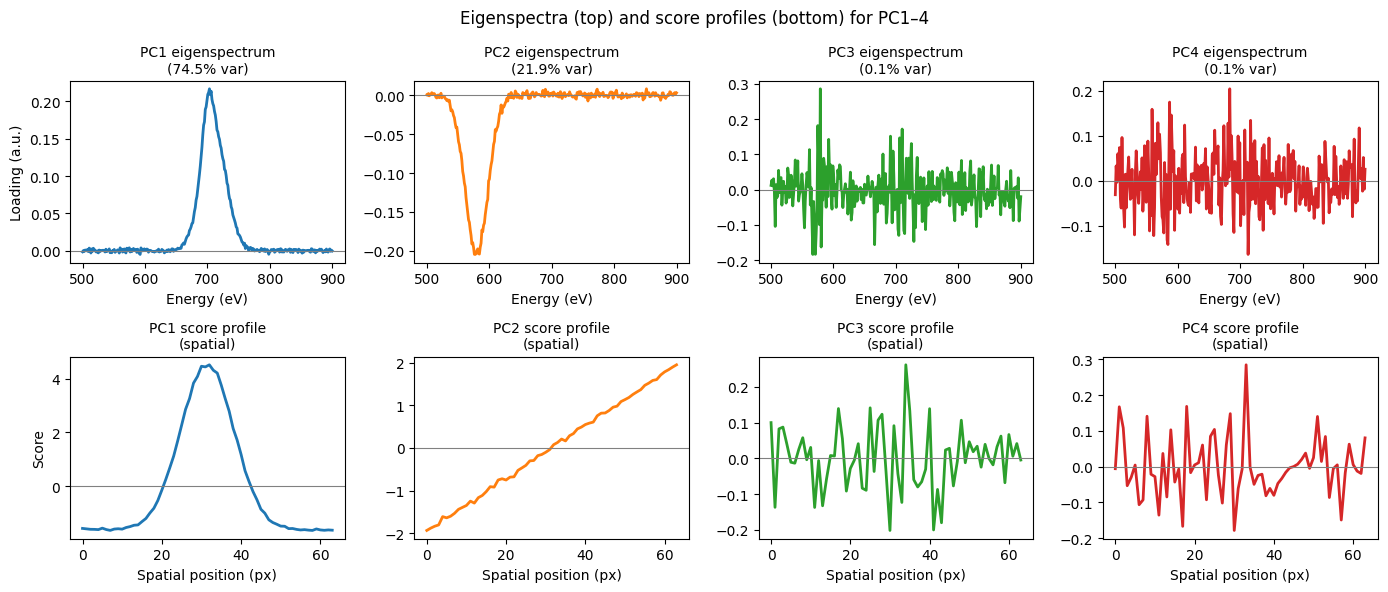

PC1 eigenspectrum: should show the dominant spectral variation (Fe-L edge shape or mixture).
PC2 eigenspectrum: second variation mode — Cr-L edge contribution.
PC3, PC4 eigenspectra: random oscillations — noise.
PC1 score: peaked at centre (Gaussian bump weight); PC2 score: linear gradient.


In [9]:
# --- Cell 9: Eigenspectra and score profiles ---

n_show = 4   # plot first 4 components
scores = X_centered @ Vt[:n_show].T   # (nx, n_show)

fig, axes = plt.subplots(2, n_show, figsize=(14, 6))

for k in range(n_show):
    pct = var_explained[k]

    # Top: eigenspectrum (loading)
    axes[0][k].plot(energy, Vt[k], color=f'C{k}', lw=2)
    axes[0][k].axhline(0, color='gray', lw=0.8)
    axes[0][k].set_title(f'PC{k+1} eigenspectrum\n({pct:.1f}% var)', fontsize=10)
    axes[0][k].set_xlabel('Energy (eV)')
    if k == 0:
        axes[0][k].set_ylabel('Loading (a.u.)')

    # Bottom: score map (spatial profile)
    axes[1][k].plot(scores[:, k], color=f'C{k}', lw=2)
    axes[1][k].axhline(0, color='gray', lw=0.8)
    axes[1][k].set_title(f'PC{k+1} score profile\n(spatial)', fontsize=10)
    axes[1][k].set_xlabel('Spatial position (px)')
    if k == 0:
        axes[1][k].set_ylabel('Score')

plt.suptitle('Eigenspectra (top) and score profiles (bottom) for PC1–4', fontsize=12)
plt.tight_layout()
plt.show()

print("PC1 eigenspectrum: should show the dominant spectral variation (Fe-L edge shape or mixture).")
print("PC2 eigenspectrum: second variation mode — Cr-L edge contribution.")
print("PC3, PC4 eigenspectra: random oscillations — noise.")
print("PC1 score: peaked at centre (Gaussian bump weight); PC2 score: linear gradient.")

## Part A6 — Self-checks

Run these asserts to confirm your understanding of the results.

In [10]:
# --- Cell 10: Self-check asserts ---

err_k1  = frob_error(reconstruct_pca(mean_spectrum, U, s, Vt, 1),  clean)
err_k2  = frob_error(reconstruct_pca(mean_spectrum, U, s, Vt, 2),  clean)
err_k20 = frob_error(reconstruct_pca(mean_spectrum, U, s, Vt, 20), clean)

# 1. Reconstruction error decreases from k=1 to k=2 (adding the second signal component)
assert err_k2 < err_k1, (
    f"k=2 should give lower error than k=1, but got err_k1={err_k1:.4f}, err_k2={err_k2:.4f}")
print(f"CHECK 1 passed: k=2 error ({err_k2:.4f}) < k=1 error ({err_k1:.4f})")

# 2. k=2 beats k=20 (noise components added for k > optimal)
assert err_k2 < err_k20, (
    f"k=2 should beat k=20 (over-inclusion of noise), got {err_k2:.4f} vs {err_k20:.4f}")
print(f"CHECK 2 passed: k=2 error ({err_k2:.4f}) < k=20 error ({err_k20:.4f})")

# 3. k=2 beats the raw noisy input
err_noisy = frob_error(noisy, clean)
assert err_k2 < err_noisy, (
    f"PCA denoising should beat the noisy input! Got {err_k2:.4f} vs {err_noisy:.4f}")
print(f"CHECK 3 passed: k=2 error ({err_k2:.4f}) < noisy baseline ({err_noisy:.4f})")

# 4. Singular values are non-increasing
assert np.all(np.diff(s) <= 1e-10), "Singular values should be non-increasing"
print("CHECK 4 passed: singular values are in descending order")

# 5. Eigenspectra have unit norm (orthonormal basis)
norms = np.linalg.norm(Vt[:4], axis=1)
assert np.allclose(norms, 1.0, atol=1e-10), f"Eigenspectra should have unit norm; got {norms}"
print("CHECK 5 passed: eigenspectra are unit-norm")

# 6. Centered data has zero column means
col_means = np.abs(X_centered.mean(axis=0)).max()
assert col_means < 1e-12, f"Centered data should have near-zero column means; max={col_means:.2e}"
print("CHECK 6 passed: centered data has zero column means")

print("\nAll self-checks passed.")

CHECK 1 passed: k=2 error (0.9122) < k=1 error (9.1948)
CHECK 2 passed: k=2 error (0.9122) < k=20 error (2.7170)
CHECK 3 passed: k=2 error (0.9122) < noisy baseline (3.8048)
CHECK 4 passed: singular values are in descending order
CHECK 5 passed: eigenspectra are unit-norm
CHECK 6 passed: centered data has zero column means

All self-checks passed.


## Exercise A — Choose K yourself

**Instructions (try before running):**

1. Look at the scree plot in Part 3 and the U-shaped error curve in Part 4.
2. Choose a value for `K_your_choice` below and write a one-sentence justification.
3. The assert at the end checks that your chosen K gives a meaningful result.

The cell ships a working solution — the `# (try this yourself)` lines are the ones to attempt first.

Your choice: K = 2
  K=1  error (underfitting baseline): 9.1948
  K= 2 error (your choice):       0.9122
  Noisy baseline:                    3.8048

Justification: I chose K=2 because the scree plot shows a clear elbow between components 2 and 3: the first two bars are much taller than the flat noise floor (~74% and ~22% variance), and the cumulative variance reaches >96% with just two components. The two eigenspectra (PC1 ≈ dominant Fe-Cr mixture, PC2 ≈ second spectral variation) both show recognisable spectral features, while PC3 onwards looks random. The U-shaped error curve confirms that K=2 minimises reconstruction error against the clean ground truth.


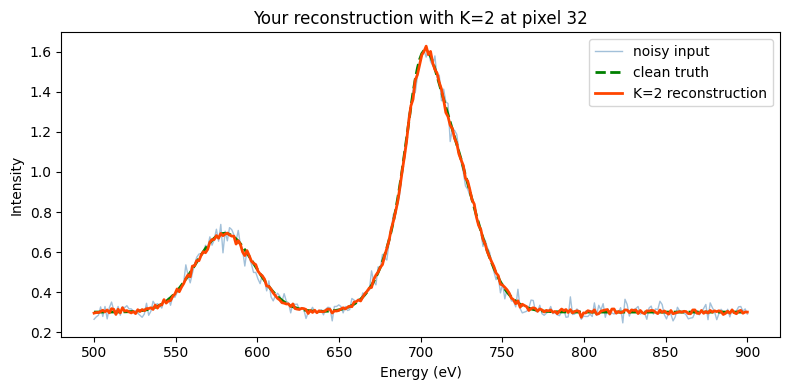

Self-check passed: K=2 beats both K=1 (underfitting) and the noisy baseline.


In [11]:
# --- Cell 11: Exercise cell (working version with try-this markers) ---

# ──────────────────────────────────────────────────────────────────────────────
# EXERCISE: choose K and justify
# ──────────────────────────────────────────────────────────────────────────────

# (try this yourself) Step 1: look at the scree plot above and choose K
K_your_choice = 2   # <-- change this to your chosen K (try 1, 3, 5, …)

# (try this yourself) Step 2: write a justification string
justification = (
    "I chose K=2 because the scree plot shows a clear elbow between components 2 and 3: "
    "the first two bars are much taller than the flat noise floor (~74% and ~22% variance), "
    "and the cumulative variance reaches >96% with just two components. The two eigenspectra "
    "(PC1 ≈ dominant Fe-Cr mixture, PC2 ≈ second spectral variation) both show recognisable "
    "spectral features, while PC3 onwards looks random. The U-shaped error curve confirms "
    "that K=2 minimises reconstruction error against the clean ground truth."
)

# (try this yourself) Step 3: compute reconstruction and error for your K
recon_yours = reconstruct_pca(mean_spectrum, U, s, Vt, K_your_choice)
err_yours   = frob_error(recon_yours, clean)
err_k1_ref  = frob_error(reconstruct_pca(mean_spectrum, U, s, Vt, 1), clean)
err_noisy_  = frob_error(noisy, clean)

print(f"Your choice: K = {K_your_choice}")
print(f"  K=1  error (underfitting baseline): {err_k1_ref:.4f}")
print(f"  K={K_your_choice:2d} error (your choice):       {err_yours:.4f}")
print(f"  Noisy baseline:                    {err_noisy_:.4f}")
print()
print("Justification:", justification)

# ── Visualise your reconstruction ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(energy, noisy[32],        lw=1, color='steelblue', alpha=0.5, label='noisy input')
ax.plot(energy, clean[32],        lw=2, color='green', linestyle='--', label='clean truth')
ax.plot(energy, recon_yours[32],  lw=2, color='orangered',
        label=f'K={K_your_choice} reconstruction')
ax.set_title(f'Your reconstruction with K={K_your_choice} at pixel 32')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Intensity')
ax.legend()
plt.tight_layout()
plt.show()

# ── Self-check ───────────────────────────────────────────────────────────────
assert err_yours < err_k1_ref, (
    f"Your K={K_your_choice} should give lower error than K=1 (underfitting). "
    f"Got {err_yours:.4f} vs {err_k1_ref:.4f}. Try K=2 or higher.")
assert err_yours < err_noisy_, (
    f"PCA denoising should beat the raw noisy input! Got {err_yours:.4f} vs {err_noisy_:.4f}. "
    f"Check that K >= 2.")
print(f"Self-check passed: K={K_your_choice} beats both K=1 (underfitting) and the noisy baseline.")

### Solution

```python
# SOLUTION — run after attempting the exercise yourself

K_your_choice = 2

justification = (
    "I chose K=2 because the scree plot shows a clear elbow between components 2 and 3: "
    "the first two bars are much taller than the flat noise floor (~74% and ~22% variance), "
    "and the cumulative variance reaches >96% with just two components. The two eigenspectra "
    "(PC1 ≈ dominant spectral variation, PC2 ≈ second independent chemical mode) both show "
    "recognisable spectral features, while PC3 onwards looks random. The U-shaped error "
    "curve confirms that K=2 minimises reconstruction error against the clean ground truth."
)

# The assert passes because:
# - The synthetic data was constructed with exactly 2 independent latent components.
# - K=1 misses the second component (underfitting).
# - K>=3 adds noise components back into the reconstruction (overfitting).
# - The scree plot elbow at K=2 exactly identifies this rank.
```

**Key takeaway:**  
The scree-plot elbow (K=2) corresponds to the number of true latent components in the data.  
Choosing K too small discards real chemical signal (underfitting).  
Choosing K too large adds noise components back into the reconstruction (overfitting).  
You can identify the optimal K from the scree plot *before* looking at the error curve.

---
# Part B — A 3-phase spectrum image with known ground truth

PCA told us *how many* things vary. Now we ask *what* they are. For that we need a 2-D
spectrum image where we know the answer.

We simulate a 48 × 48 pixel map with 300 channels (400–900 eV, background already removed):

| Phase | Edges | Where |
|---|---|---|
| TiO₂-like | Ti-L₂,₃ (456 eV) + O-K (532 eV) | particle top-left |
| FeO-like  | Fe-L₂,₃ (708 eV) + O-K (532 eV) | particle bottom-right |
| Ni metal  | Ni-L₂,₃ (855 eV) | matrix |

Each pixel is a **linear mixture** $\mathbf{x}_i = \sum_k a_{ik}\mathbf{m}_k$ with abundances $a_{ik}\ge 0$, $\sum_k a_{ik}=1$
(pixels at particle boundaries are genuinely mixed). Poisson noise is added on top.
Note the **shared O-K edge** — both oxides contain oxygen, so no single channel identifies a phase.

Data matrix X_si: (2304, 300)   (N pixels × D channels)
Mean counts per channel: 8.5   min: 0


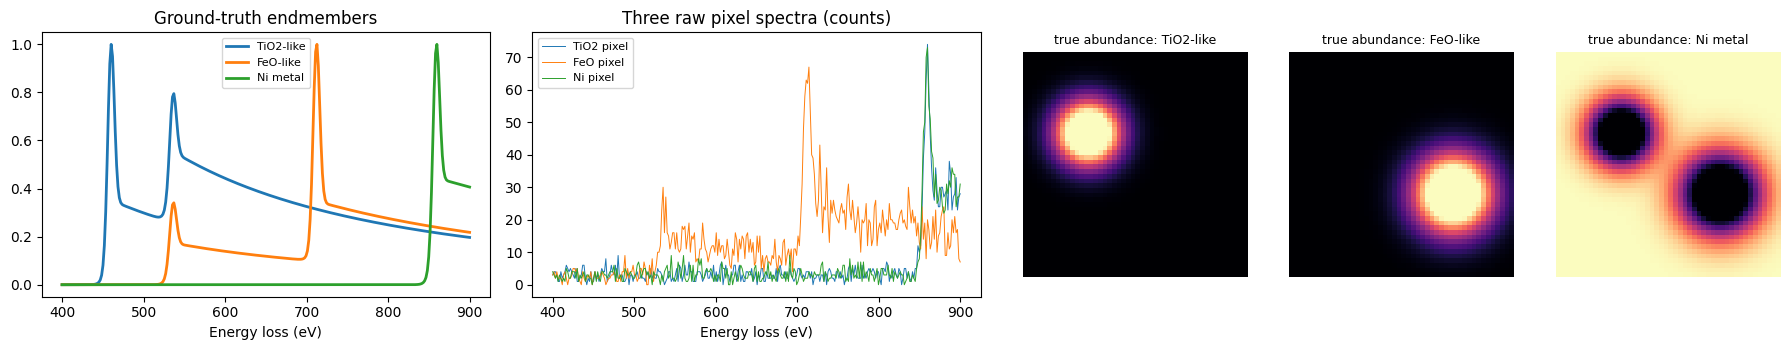

In [12]:
# --- Cell B1: Synthetic 3-phase spectrum image ---

def edge(E, onset, jump, wl=0.0, wl_w=4.0, width=3.0):
    """Idealised ionisation edge: smoothed step with E^-2 tail plus a white line."""
    step  = 1.0 / (1.0 + np.exp(-(E - onset) / width))
    tail  = (E / onset) ** -2.0
    white = wl * np.exp(-0.5 * ((E - onset - 4) / wl_w) ** 2)
    return jump * step * tail + white

NY, NX, NE = 48, 48, 300
E_si = np.linspace(400, 900, NE)

M_true = np.stack([
    edge(E_si, 456, 0.6, wl=1.2) + edge(E_si, 532, 0.5,  wl=0.5),   # TiO2-like
    edge(E_si, 708, 0.5, wl=1.4) + edge(E_si, 532, 0.35, wl=0.4),   # FeO-like
    edge(E_si, 855, 0.7, wl=1.0),                                   # Ni metal
])
M_true /= M_true.max(axis=1, keepdims=True)
phase_names = ["TiO2-like", "FeO-like", "Ni metal"]

def make_abundances(ny=NY, nx=NX):
    yy, xx = np.mgrid[0:ny, 0:nx] / max(ny, nx)
    a1 = np.clip(1.6 * np.exp(-((xx - 0.28)**2 + (yy - 0.35)**2) / 0.02), 0, 1)
    a2 = np.clip(1.6 * np.exp(-((xx - 0.72)**2 + (yy - 0.62)**2) / 0.03), 0, 1)
    a3 = np.clip(1.0 - a1 - a2, 0, None)
    A = np.stack([a1, a2, a3], axis=-1)
    return (A / A.sum(axis=-1, keepdims=True)).reshape(-1, 3)   # (N, 3), rows sum to 1

A_true = make_abundances()
DOSE   = 60.0                         # counts per unit intensity
OFFSET = 0.05                         # small residual background in every channel
X_clean = A_true @ M_true + OFFSET    # (N, NE)
X_si    = rng.poisson(X_clean * DOSE).astype(float)   # raw COUNTS (N, NE)

print("Data matrix X_si:", X_si.shape, "  (N pixels × D channels)")
print(f"Mean counts per channel: {X_si.mean():.1f}   min: {X_si.min():.0f}")
assert np.allclose(A_true.sum(1), 1)

fig, ax = plt.subplots(1, 5, figsize=(18, 3.6), gridspec_kw={"width_ratios": [2, 2, 1, 1, 1]})
for k in range(3):
    ax[0].plot(E_si, M_true[k], lw=2, label=phase_names[k])
    ax[k + 2].imshow(A_true[:, k].reshape(NY, NX), cmap="magma", vmin=0, vmax=1)
    ax[k + 2].set_title(f"true abundance: {phase_names[k]}", fontsize=9); ax[k + 2].axis("off")
ax[0].set_title("Ground-truth endmembers"); ax[0].set_xlabel("Energy loss (eV)"); ax[0].legend(fontsize=8)
for idx, lab in [(35 * NX + 13, "TiO2 pixel"), (30 * NX + 35, "FeO pixel"), (5 * NX + 45, "Ni pixel")]:
    ax[1].plot(E_si, X_si[idx], lw=0.7, label=lab)
ax[1].set_title("Three raw pixel spectra (counts)"); ax[1].set_xlabel("Energy loss (eV)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Part C — PCA vs NMF on the same data

## C1 — PCA with Poisson weighting

As in the lecture, we weight the counts first (Keenan–Kotula): divide by $\sqrt{\text{pixel total}\times\text{mean spectrum}}$
so every entry has roughly unit noise variance. Then centre and SVD.

findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


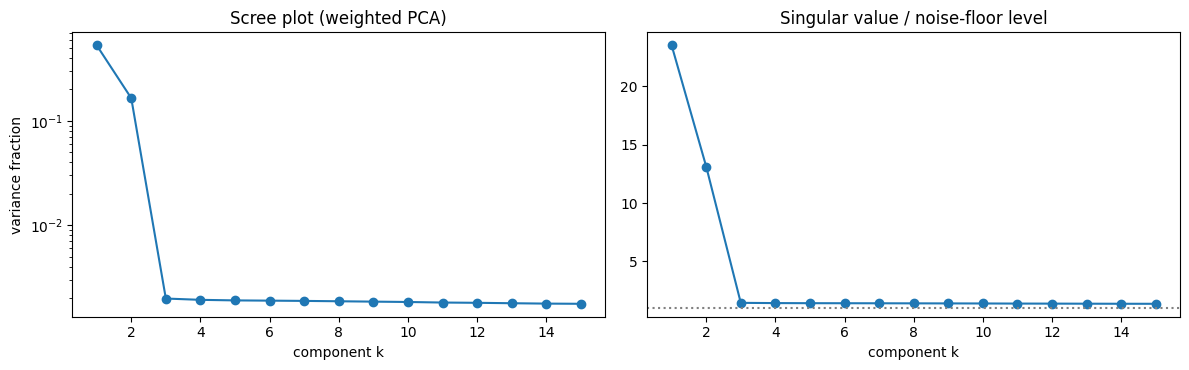

variance fractions of first 5 PCs: [0.5293 0.1648 0.002  0.0019 0.0019]
Three phases with sum-to-one → rank K-1 = 2 after centering. Elbow at k=2 ⇒ K = 3 phases.


In [13]:
# --- Cell C1: Weighted PCA of the spectrum image ---

g = X_si.sum(1, keepdims=True) / X_si.sum() * X_si.shape[0]     # relative pixel totals (N,1)
h = X_si.mean(0, keepdims=True)                                 # mean spectrum (1,D)
Wt = 1.0 / np.sqrt(g * h)                                       # weights (N,D)

Xw  = X_si * Wt
mu_w = Xw.mean(0)
U_si, s_si, Vt_si = np.linalg.svd(Xw - mu_w, full_matrices=False)
var_si = s_si**2 / (s_si**2).sum()

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].semilogy(np.arange(1, 16), var_si[:15], "o-")
ax[0].set_title("Scree plot (weighted PCA)"); ax[0].set_xlabel("component k"); ax[0].set_ylabel("variance fraction")
ax[1].plot(np.arange(1, 16), s_si[:15] / s_si[15:].mean(), "o-")
ax[1].axhline(1, color="gray", ls=":"); ax[1].set_title("Singular value / noise-floor level")
ax[1].set_xlabel("component k")
plt.tight_layout(); plt.show()
print("variance fractions of first 5 PCs:", var_si[:5].round(4))
print("Three phases with sum-to-one → rank K-1 = 2 after centering. Elbow at k=2 ⇒ K = 3 phases.")

**Why does a 3-phase sample give only 2 significant PCs?** Because the abundances sum to one:
$a_{i3} = 1 - a_{i1} - a_{i2}$, so after subtracting the mean spectrum only $K-1 = 2$ independent directions
remain. The mean spectrum is the "missing" component. So: **number of phases = elbow + 1** when closure holds
(and the data are centred). Keep this in mind when you read scree plots of real data.

## C2 — NMF with a Poisson (KL) loss

NMF works on the **raw, non-negative counts** (no centring — centring would create negative values).
We use `beta_loss="kullback-leibler"`, which is the Poisson likelihood (Week 2!).

NMF finished after 90 iterations


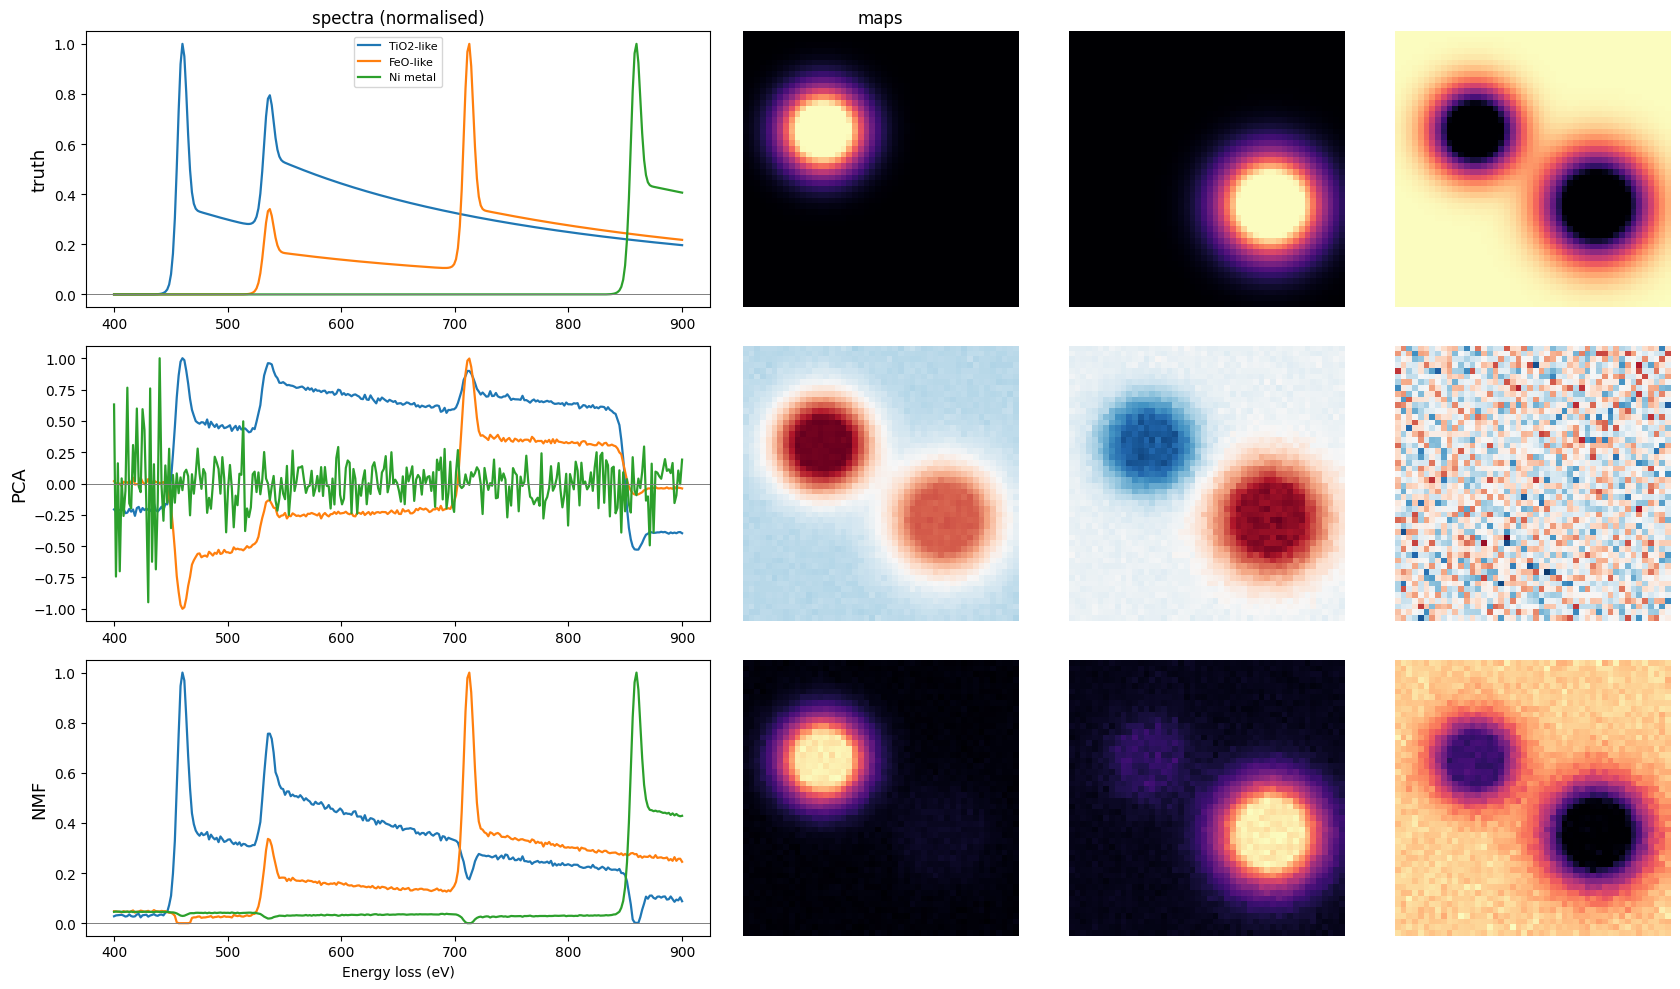

In [14]:
# --- Cell C2: PCA components (unweighted back) and NMF components ---
K = 3

# PCA components in the original (unweighted) space, for plotting only
pca_spectra = Vt_si[:K] / np.sqrt(h)          # undo channel weighting for interpretability
pca_maps    = U_si[:, :K] * s_si[:K]          # (N, K) scores

nmf = NMF(n_components=K, init="nndsvda", beta_loss="kullback-leibler", solver="mu",
          max_iter=400, tol=1e-5, random_state=0)
W_nmf = nmf.fit_transform(X_si)               # (N, K)
H_nmf = nmf.components_                       # (K, D)
print(f"NMF finished after {nmf.n_iter_} iterations")


def match_to_truth(S_est, S_true=M_true):
    """Hungarian matching of estimated to true spectra by |correlation|.
    Returns permutation (est index for each true k) and the matched correlations."""
    corr = np.corrcoef(np.vstack([S_true, S_est]))[:len(S_true), len(S_true):]
    rows, cols = linear_sum_assignment(-np.abs(corr))
    return cols, corr[rows, cols]


perm_nmf, corr_nmf = match_to_truth(H_nmf)
perm_pca, corr_pca = match_to_truth(pca_spectra)
H_nmf, W_nmf = H_nmf[perm_nmf], W_nmf[:, perm_nmf]
pca_spectra, pca_maps = pca_spectra[perm_pca], pca_maps[:, perm_pca]

fig, ax = plt.subplots(3, 4, figsize=(17, 10), gridspec_kw={"width_ratios": [2, 1, 1, 1]})
rows = [("truth", M_true, A_true, "magma"),
        ("PCA",   pca_spectra, pca_maps, "RdBu_r"),
        ("NMF",   H_nmf / H_nmf.max(1, keepdims=True), W_nmf, "magma")]
for r, (lab, S, T, cmap) in enumerate(rows):
    for k in range(K):
        ax[r, 0].plot(E_si, S[k] / np.abs(S[k]).max(), lw=1.6, label=phase_names[k] if r == 0 else None)
        im = T[:, k].reshape(NY, NX)
        v = np.abs(im).max()
        ax[r, k + 1].imshow(im, cmap=cmap, vmin=-v if cmap == "RdBu_r" else 0, vmax=v)
        ax[r, k + 1].axis("off")
    ax[r, 0].axhline(0, color="gray", lw=0.7); ax[r, 0].set_ylabel(lab, fontsize=13)
ax[0, 0].legend(fontsize=8); ax[2, 0].set_xlabel("Energy loss (eV)")
ax[0, 0].set_title("spectra (normalised)"); ax[0, 1].set_title("maps")
plt.tight_layout(); plt.show()

## C3 — Quantitative comparison with the ground truth

Never judge a decomposition by eye alone when a ground truth (or a physical check) exists. Two metrics:

- **Spectral correlation** between each recovered spectrum and its matched true endmember (1 = identical shape).
- **Abundance RMSE**: NMF's $\mathbf{W}$ has arbitrary scale (the scale can move between $\mathbf{W}$ and $\mathbf{H}$), so we
  rescale each NMF component by the max of its spectrum and then **normalise rows to sum to one** before comparing.

In [15]:
# --- Cell C3: Metrics against ground truth ---

def abundance_from_nmf(W, H):
    """Put the scale into W (spectra normalised to max 1), then enforce closure per pixel."""
    Ws = W * H.max(1)[None, :]
    return Ws / Ws.sum(1, keepdims=True)

A_nmf = abundance_from_nmf(W_nmf, H_nmf)
rmse_nmf = np.sqrt(((A_nmf - A_true) ** 2).mean(0))

print("Spectral correlation with ground truth (per phase):")
print(f"{'':12s} {'PCA':>8s} {'NMF':>8s}")
for k in range(K):
    print(f"{phase_names[k]:12s} {abs(corr_pca[k]):8.3f} {corr_nmf[k]:8.3f}")
print(f"\nNMF abundance RMSE per phase: {rmse_nmf.round(3)}   (abundances are in [0, 1])")

# Self-checks
assert corr_nmf.min() > 0.9, "NMF should recover all three endmember shapes (corr > 0.9)"
assert np.mean(corr_nmf) > np.mean(np.abs(corr_pca)), "NMF spectra should match the truth better than PCA loadings"
assert rmse_nmf.max() < 0.1, "NMF abundances should be within 0.1 RMSE of the truth"
print("\nSelf-checks passed: NMF spectra ≈ phases; PCA loadings are signed mixtures (lower correlation).")

Spectral correlation with ground truth (per phase):
                  PCA      NMF
TiO2-like       0.711    0.963
FeO-like        0.800    0.997
Ni metal        0.004    0.999

NMF abundance RMSE per phase: [0.068 0.056 0.062]   (abundances are in [0, 1])

Self-checks passed: NMF spectra ≈ phases; PCA loadings are signed mixtures (lower correlation).


**What you should see:** PCA loadings correlate only partly with the true spectra — they are *difference spectra*
(e.g. oxide − metal) with negative lobes, and PC3 is noise. NMF recovers all three phase spectra with correlations
above ~0.95 and abundance maps within a few percent. Both factorisations reconstruct the data almost equally well —
they differ in the **basis** they pick inside the same subspace.

---
# Part D — Inside NMF

## Exercise D1 — Write the multiplicative updates yourself

Lee & Seung's updates for the Frobenius loss $\|\mathbf{X}-\mathbf{WH}\|_F^2$:

$$\mathbf{H} \leftarrow \mathbf{H}\odot\frac{\mathbf{W}^T\mathbf{X}}{\mathbf{W}^T\mathbf{W}\mathbf{H}},\qquad
\mathbf{W} \leftarrow \mathbf{W}\odot\frac{\mathbf{X}\mathbf{H}^T}{\mathbf{W}\mathbf{H}\mathbf{H}^T}$$

(all products in the fraction are matrix products; $\odot$ and the division are element-wise).

**Task:** complete `nmf_mu` below — the two update lines are marked `# (try this yourself)`.
Add a tiny `eps` to the denominators to avoid division by zero. The check verifies that the loss never increases.

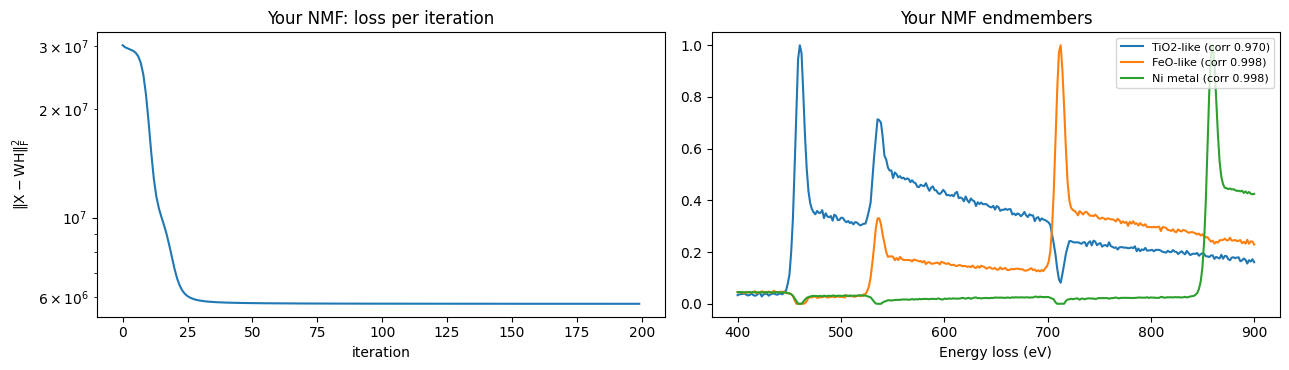

Self-checks passed: non-negative factors, monotone loss, min corr = 0.970


In [16]:
# --- Cell D1: Exercise — multiplicative-update NMF (working version with try-this markers) ---

def nmf_mu(X, K, n_iter=300, seed=0, eps=1e-10):
    """Frobenius-loss NMF by Lee-Seung multiplicative updates.
    Returns W (N,K), H (K,D) and the loss history."""
    r = np.random.default_rng(seed)
    scale = np.sqrt(X.mean() / K)
    W = r.uniform(0.1, 1.0, (X.shape[0], K)) * scale      # strictly positive init!
    H = r.uniform(0.1, 1.0, (K, X.shape[1])) * scale
    losses = []
    for _ in range(n_iter):
        H *= (W.T @ X) / (W.T @ W @ H + eps)               # (try this yourself)
        W *= (X @ H.T) / (W @ H @ H.T + eps)               # (try this yourself)
        losses.append(np.linalg.norm(X - W @ H) ** 2)
    return W, H, np.array(losses)


W_mu, H_mu, loss_mu = nmf_mu(X_si, K=3, n_iter=200, seed=0)
perm_mu, corr_mu = match_to_truth(H_mu)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].semilogy(loss_mu); ax[0].set_xlabel("iteration"); ax[0].set_ylabel(r"$\|X-WH\|_F^2$")
ax[0].set_title("Your NMF: loss per iteration")
for k in range(3):
    hk = H_mu[perm_mu[k]]
    ax[1].plot(E_si, hk / hk.max(), lw=1.5, label=f"{phase_names[k]} (corr {corr_mu[k]:.3f})")
ax[1].set_title("Your NMF endmembers"); ax[1].legend(fontsize=8); ax[1].set_xlabel("Energy loss (eV)")
plt.tight_layout(); plt.show()

# Self-checks
assert (W_mu >= 0).all() and (H_mu >= 0).all(), "Factors must stay non-negative"
rel_increase = np.max(np.diff(loss_mu) / loss_mu[:-1])
assert rel_increase < 1e-6, f"Loss must be non-increasing (max relative increase {rel_increase:.2e})"
assert corr_mu.min() > 0.85, "Your NMF should recover the three phases"
print(f"Self-checks passed: non-negative factors, monotone loss, min corr = {corr_mu.min():.3f}")

### Solution

```python
def nmf_mu(X, K, n_iter=300, seed=0, eps=1e-10):
    r = np.random.default_rng(seed)
    scale = np.sqrt(X.mean() / K)
    W = r.uniform(0.1, 1.0, (X.shape[0], K)) * scale
    H = r.uniform(0.1, 1.0, (K, X.shape[1])) * scale
    losses = []
    for _ in range(n_iter):
        H *= (W.T @ X) / (W.T @ W @ H + eps)      # gradient step with step size H / (W^T W H)
        W *= (X @ H.T) / (W @ H @ H.T + eps)      # same for W
        losses.append(np.linalg.norm(X - W @ H) ** 2)
    return W, H, np.array(losses)
```

**Why non-negativity is automatic:** every factor in the update is a product/ratio of non-negative numbers.
**Why initialise strictly positive:** a zero entry stays zero forever under multiplicative updates.
**Why the loss decreases:** the update is gradient descent with a per-element step size
$\eta = \mathbf{H}/(\mathbf{W}^T\mathbf{W}\mathbf{H})$ that makes each step minimise a quadratic upper bound of the loss.

## Experiment D2 — Rotational ambiguity

NMF worked well above because every phase has **pure pixels** (particle centres, matrix far from particles).
Then the data simplex touches its vertices and the factorisation is (nearly) unique.

Now we **remove the pure pixels**: squeeze all abundances towards the mean, $\mathbf{a}_i' = 0.4\,\mathbf{a}_i + 0.6\,\bar{\mathbf{a}}$.
Every pixel is now a mixture. We run NMF from 5 random initialisations on both datasets and compare how much the
recovered endmembers vary between restarts.

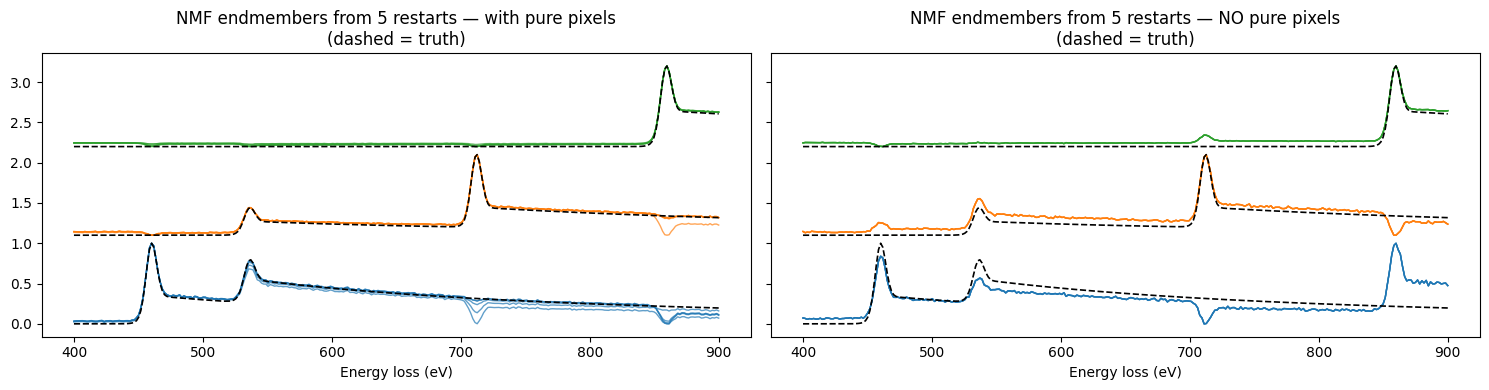

mean spectral spread across restarts:  pure pixels 0.0111   no pure pixels 0.0005
mean corr with truth:                   pure pixels 0.985   no pure pixels 0.830



X_mixed: ||X - WH|| for NMF solution = 2400.2   for the TRUE factors = 2426.7
NMF fits the data as well as (or better than) the truth, yet its spectra are wrong: an identifiability problem,
not an optimisation problem.


In [17]:
# --- Cell D2: Restarts with and without pure pixels ---
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

A_mixed = 0.4 * A_true + 0.6 * A_true.mean(0, keepdims=True)
X_mixed = rng.poisson((A_mixed @ M_true + OFFSET) * DOSE).astype(float)

def restart_spread(X, seeds=range(5)):
    specs, corrs = [], []
    for sd in seeds:
        m = NMF(n_components=3, init="random", solver="cd",   # fast coordinate descent
                max_iter=400, tol=1e-5, random_state=sd)
        m.fit(X)
        p, c = match_to_truth(m.components_)
        S = m.components_[p]
        specs.append(S / S.max(1, keepdims=True)); corrs.append(c)
    specs = np.array(specs)                    # (n_seeds, K, D)
    return specs, np.array(corrs)

specs_pure,  corrs_pure  = restart_spread(X_si)
specs_mixed, corrs_mixed = restart_spread(X_mixed)

fig, ax = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
for a, specs, title in [(ax[0], specs_pure, "with pure pixels"), (ax[1], specs_mixed, "NO pure pixels")]:
    for k in range(3):
        for sd in range(specs.shape[0]):
            a.plot(E_si, specs[sd, k] + 1.1 * k, color=f"C{k}", lw=1, alpha=0.7)
        a.plot(E_si, M_true[k] + 1.1 * k, color="w" if plt.rcParams["axes.facecolor"] != "white" else "k",
               lw=1.2, ls="--")
    a.set_title(f"NMF endmembers from 5 restarts — {title}\n(dashed = truth)")
    a.set_xlabel("Energy loss (eV)")
plt.tight_layout(); plt.show()

spread_pure  = specs_pure.std(0).mean()
spread_mixed = specs_mixed.std(0).mean()
print(f"mean spectral spread across restarts:  pure pixels {spread_pure:.4f}   no pure pixels {spread_mixed:.4f}")
print(f"mean corr with truth:                   pure pixels {corrs_pure.mean():.3f}   no pure pixels {corrs_mixed.mean():.3f}")
# The decisive test: is the (wrong) NMF answer on X_mixed a WORSE fit than the truth?
m = NMF(n_components=3, init="nndsvda", solver="cd", max_iter=400, tol=1e-5, random_state=0).fit(X_mixed)
err_nmf  = np.linalg.norm(X_mixed - m.transform(X_mixed) @ m.components_)
err_true = np.linalg.norm(X_mixed - (A_mixed * DOSE) @ (M_true + OFFSET))   # true factors (closure absorbs OFFSET)
print(f"\nX_mixed: ||X - WH|| for NMF solution = {err_nmf:.1f}   for the TRUE factors = {err_true:.1f}")
assert err_nmf <= 1.01 * err_true, "NMF should fit at least as well as the truth"
print("NMF fits the data as well as (or better than) the truth, yet its spectra are wrong: an identifiability problem,")
print("not an optimisation problem.")


**Interpretation.** Without pure pixels the data occupy only the *inside* of the simplex. Many different enclosing
triangles (sets of non-negative endmembers) reproduce the data equally well — that is **rotational ambiguity**,
$\mathbf{X}=\mathbf{CS}^T=(\mathbf{CT})(\mathbf{T}^{-1}\mathbf{S}^T)$. Symptoms: the endmembers may depend on the random seed —
or, as here, the solver converges *consistently* to the same wrong answer (low correlation with the truth, "pure" spectra that
contain copies of other phases' edges). Consistency across restarts is therefore **not** proof of correctness. The last print
shows the core issue: the NMF answer fits the data at least as well as the true factors, so a better optimiser cannot help. Only extra information (constraints, reference spectra, physics) does.

**Question to answer in one sentence:** why does NMF recover the phases on `X_si` but not on `X_mixed`, although both fits are equally good?

## Optional D3 — Minimal MCR-ALS with closure

MCR-ALS alternates two least-squares problems, $\mathbf{C}\leftarrow\arg\min\|\mathbf{X}-\mathbf{C}\mathbf{S}^T\|$ and
$\mathbf{S}\leftarrow\arg\min\|\mathbf{X}-\mathbf{C}\mathbf{S}^T\|$, and applies **constraints** after each step.
Here: non-negativity (clip at 0) for both, plus **closure** (abundances sum to one). Initialisation: k-means centroids
of the spectra (a crude "purest-spectra" guess).

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x712d4cea1360>
Traceback (most recent call last):
  File "/home/philipp/projects/_public_presentations/.venv/lib/python3.10/site-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/home/philipp/projects/_public_presentations/.venv/lib/python3.10/site-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
  File "/home/philipp/projects/_public_presentations/.venv/lib/python3.10/site-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
  File "/home/philipp/miniforge3/envs/py4dstem/lib/python3.10/ctypes/__init__.py", line 374, in __init__
    self._handle = _dlopen(self._name, mode)
OSError: /home/philipp/projects/_public_presentations/.venv/lib/python3.10/s

MCR-ALS relative residual: 0.2192
spectral corr with truth: [0.997 0.998 1.   ]
abundance RMSE (closure built in): [0.027 0.034 0.031]    NMF was: [0.068 0.056 0.062]


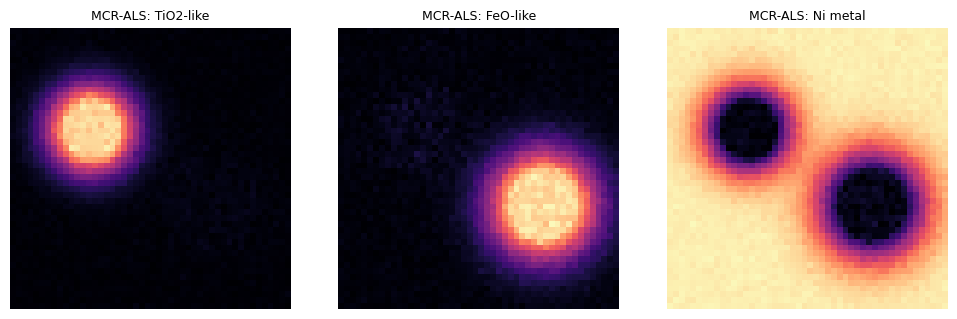

Note: the constant OFFSET is shared by all phases, so closure lets MCR absorb it into the spectra —
closure is a *physical* statement (fractions add up to 100 %) that NMF alone does not know.


In [18]:
# --- Cell D3 (optional): MCR-ALS with non-negativity + closure ---
from sklearn.cluster import KMeans

def mcr_als(X, S0, n_iter=60, closure=True):
    S = S0.copy()                                   # (K, D) spectra
    for _ in range(n_iter):
        C = np.linalg.lstsq(S.T, X.T, rcond=None)[0].T   # (N, K)  C-step (least squares)
        C = np.clip(C, 0, None)                           # non-negativity
        if closure:
            C = C / np.maximum(C.sum(1, keepdims=True), 1e-12)   # closure: rows sum to 1
        S = np.linalg.lstsq(C, X, rcond=None)[0]              # (K, D)  S-step
        S = np.clip(S, 0, None)
    resid = np.linalg.norm(X - C @ S) / np.linalg.norm(X)
    return C, S, resid

S0 = KMeans(n_clusters=3, n_init=5, random_state=0).fit(X_si).cluster_centers_
C_mcr, S_mcr, res_mcr = mcr_als(X_si, S0)
perm_mcr, corr_mcr = match_to_truth(S_mcr)
C_mcr = C_mcr[:, perm_mcr]
rmse_mcr = np.sqrt(((C_mcr - A_true) ** 2).mean(0))

print(f"MCR-ALS relative residual: {res_mcr:.4f}")
print("spectral corr with truth:", corr_mcr.round(3))
print("abundance RMSE (closure built in):", rmse_mcr.round(3), "   NMF was:", rmse_nmf.round(3))

fig, ax = plt.subplots(1, 3, figsize=(10, 3.2))
for k in range(3):
    ax[k].imshow(C_mcr[:, k].reshape(NY, NX), cmap="magma", vmin=0, vmax=1)
    ax[k].set_title(f"MCR-ALS: {phase_names[k]}", fontsize=9); ax[k].axis("off")
plt.tight_layout(); plt.show()
print("Note: the constant OFFSET is shared by all phases, so closure lets MCR absorb it into the spectra —")
print("closure is a *physical* statement (fractions add up to 100 %) that NMF alone does not know.")

## Summary

| Concept | What you did |
|---------|-------------|
| **Data matrix** | Line scan (nx, ne) and spectrum image (ny·nx, ne); observations in rows |
| **Centering + SVD** | `np.linalg.svd(X - mean, full_matrices=False)` → U, s, Vt |
| **Scree plot** | Elbow = signal/noise boundary; with closure, #phases = elbow + 1 |
| **PCA denoising** | `(U[:,:k] * s[:k]) @ Vt[:k] + mean`; U-shaped error vs k |
| **Poisson weighting** | Divide counts by √(pixel total × mean spectrum) before PCA |
| **NMF** | `NMF(beta_loss="kullback-leibler", solver="mu")` on raw counts → phase-like spectra, non-negative maps |
| **Ground-truth check** | Hungarian matching, spectral correlation, abundance RMSE |
| **Multiplicative updates** | `H *= (WᵀX)/(WᵀWH)`, `W *= (XHᵀ)/(WHHᵀ)`; non-negativity for free, monotone loss |
| **Rotational ambiguity** | Without pure pixels, NMF endmembers depend on the seed |
| **MCR-ALS** | Alternating LS + non-negativity + closure |

**Coming next (Week 4 — Regression, optimisation & honest validation):**
Linear regression is the projection geometry you used today, gradient descent generalises the
multiplicative update, Ridge fixes ill-conditioning — and you will see why fitting PCA *before* the
train/test split leaks information.